In [4]:
import pandas as pd

df = pd.read_csv(
    "/Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/seagrass/Fw_ Following up on modeling conversation at the Royal Society Meeting/SG_Cstock_modeling/data/For_modeling_df_shallow_carbon_density.csv"
)
print(df.shape)
df.head()

(3680, 52)


,number_id_final_version,latitude,longitude,dry_bulk_density_g_cm3,organic_carbon_percent,carbon_density_g_c_cm3,seagrass_species,sediment_mean_depth_cm,KD_closest,PBS443_closest,...,wave_height_VHM0_mean_m_closest,wave_height_VHM0_p95_m_closest,SW_KE_mean_cm2_s2_closest,SW_KE_p95_cm2_s2_closest,Daily_max_wave_height_mean_m_closest,Daily_mean_wave_height_mean_m_closest,Daily_std_wave_height_mean_m_closest,No_sig_wave_heights_mean_closest,Region,random_core_variable
0,6271,56.0953,14.7202,1.327393,0.173659,0.002305,Unspecified,5.087064,1.8928,0.00497,...,0.595698,1.37,13.527889,30.938845,1.346317,0.952116,0.218566,37.845127,Baltic Sea,Baltic Sea_Furumon_NA_2021_NA_NA_56.0953_14.72...
1,6272,56.0953,14.7202,1.305520,0.157340,0.002054,Unspecified,17.785360,1.8928,0.00497,...,0.595698,1.37,13.527889,30.938845,1.346317,0.952116,0.218566,37.845127,Baltic Sea,Baltic Sea_Furumon_NA_2021_NA_NA_56.0953_14.72...
2,6273,56.0953,14.7202,1.296560,0.157470,0.002042,Unspecified,26.022793,1.8928,0.00497,...,0.595698,1.37,13.527889,30.938845,1.346317,0.952116,0.218566,37.845127,Baltic Sea,Baltic Sea_Furumon_NA_2021_NA_NA_56.0953_14.72...
3,6274,55.4575,14.2785,1.293173,0.641835,0.008300,Unspecified,8.584421,1.2402,0.00547,...,0.734222,1.67,13.157668,29.555975,1.346317,0.952116,0.218566,37.845127,Baltic Sea,Baltic Sea_Skillinge_NA_2021_NA_NA_55.4575_14....
4,6275,55.4575,14.2785,1.228165,0.669481,0.008222,Unspecified,9.856186,1.2402,0.00547,...,0.734222,1.67,13.157668,29.555975,1.346317,0.952116,0.218566,37.845127,Baltic Sea,Baltic Sea_Skillinge_NA_2021_NA_NA_55.4575_14....


<Figure size 2000x600 with 0 Axes>

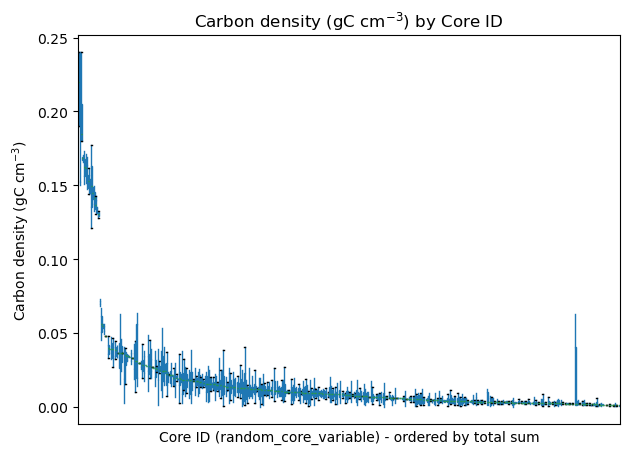

In [18]:
import matplotlib.pyplot as plt

# Calculate sum of carbon_density_g_c_cm3 for each core and sort descending
core_sum = (
    df.groupby("random_core_variable")["carbon_density_g_c_cm3"]
    .median()
    .sort_values(ascending=False)
)
core_order = core_sum.index.tolist()

plt.figure(figsize=(20, 6))

# Map each row's core to its ordered position
core_pos = df["random_core_variable"].map({k: v for v, k in enumerate(core_order)})

# Create boxplot, but sorted by core total sum
df["core_order"] = pd.Categorical(
    df["random_core_variable"], categories=core_order, ordered=True
)
df_sorted = df.sort_values("core_order")

df_sorted.boxplot(
    column="carbon_density_g_c_cm3",
    by="core_order",
    positions=range(len(core_order)),  # each position matches sorted order
    grid=False,
    patch_artist=True,
    showfliers=False,
)
plt.xlabel("Core ID (random_core_variable) - ordered by total sum")
plt.ylabel("carbon_density_g_c_cm3")
plt.title("Carbon density (gC cm$^{-3}$) by Core ID")
plt.suptitle("")
plt.xticks(ticks=range(len(core_order)), labels=core_order, rotation=90, fontsize=7)

# remove xtick labels if you want
plt.xticks([])
plt.ylabel("Carbon density (gC cm$^{-3}$)")
plt.tight_layout()
plt.show()


In [20]:
df.sediment_mean_depth_cm.describe()

count    3680.000000
mean       23.892245
std        22.265793
min         0.271350
25%         5.948786
50%        17.487908
75%        35.145828
max        99.810427
Name: sediment_mean_depth_cm, dtype: float64

In [19]:
df.columns

Index(['number_id_final_version', 'latitude', 'longitude',
       'dry_bulk_density_g_cm3', 'organic_carbon_percent',
       'carbon_density_g_c_cm3', 'seagrass_species', 'sediment_mean_depth_cm',
       'KD_closest', 'PBS443_closest', 'Chla_closest', 'RRS620_closest',
       'CDOM_closest', 'RRS443_closest', 'bottomT_mean_C_closest',
       'bottomT_p95_C_closest', 'sal_mean_0.5m_closest',
       'sal_p05_0.5m_closest', 'SST_daily_mean_C_closest',
       'SST_daily_p95_C_closest', 'Surf_talk_mean_umol_kg_closest',
       'Surf_talk_p95_umol_kg_closest', 'Surf_spco2_mean_uatm_closest',
       'Surf_spco2_p95_uatm_closest', 'Surf_fgco2_mean_molC_m2_yr_closest',
       'Surf_fgco2_p95_molC_m2_yr_closest', 'fe_mean_1.5m_mmol_m3_closest',
       'no3_mean_1.5m_mmol_m3_closest', 'po4_mean_1.5m_mmol_m3_closest',
       'phyc_mean_0.5m_mmol_m3_closest', 'nppv_mean_0.5m_mg_m3_day_closest',
       'pH_mean_1.5m_closest', 'pH_p05_1.5m_closest',
       'spco2_monthly_mean_Pa_closest', 'spco2_mont

In [56]:
model.predict(x)

array([24.60198652, 45.01080822, 51.40489996, ...,  2.63576684,
        6.84680135, 28.48639206])

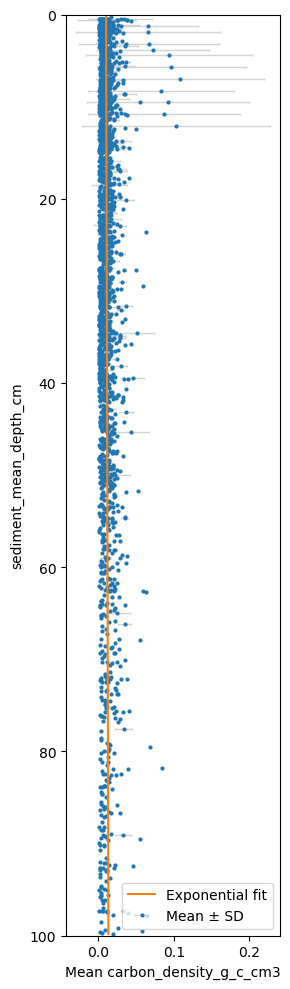

In [ ]:
# Plot the mean (with standard deviation) value at each level of the depth
mean = df.groupby("sediment_mean_depth_cm")["carbon_density_g_c_cm3"].mean()
std = df.groupby("sediment_mean_depth_cm")["carbon_density_g_c_cm3"].std()
depths = mean.index.values
means = mean.values
stds = std.values

fig, ax = plt.subplots(figsize=(3, 10))
ax.errorbar(
    means,
    depths,
    xerr=stds,
    fmt="o",
    label="Mean ± SD",
    markersize=2,
    color="tab:blue",
    ecolor="lightgray",
    elinewidth=1,
    capsize=1,
)

# Fit an exponential decay curve: mean = a * exp(-b * depth) + c
from scipy.optimize import curve_fit
import numpy as np


def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c


# Provide an initial guess to help curve_fit
p0 = [means.max(), 0.05, means.min()]
popt, pcov = curve_fit(exp_func, depths, means, p0=p0)
fit_means = exp_func(depths, *popt)

# Uncertainty (confidence interval, 95%) from parameter covariance
import scipy.stats as stats

alpha = 0.05
n_params = len(popt)
param_sdev = np.sqrt(np.diag(pcov))
# Sample from parameter distribution for curve envelope
n_samples = 1000
param_samples = np.random.multivariate_normal(popt, pcov, n_samples)
fit_samples = np.array([exp_func(depths, *params) for params in param_samples])
lower = np.percentile(fit_samples, 100 * alpha / 2, axis=0)
upper = np.percentile(fit_samples, 100 * (1 - alpha / 2), axis=0)

ax.plot(fit_means, depths, label="Exponential fit", color="tab:orange", zorder=10)
# ax.fill_betweenx(
#     depths, lower, upper, color="tab:orange", alpha=0.2, label="95% CI of fit"
# )

# Reverse the y-axis (so 0 is at the top)
ax.invert_yaxis()
ax.set_ylim(100, 0)
ax.set_xlabel("Mean carbon_density_g_c_cm3")
ax.set_ylabel("sediment_mean_depth_cm")
ax.legend()
plt.tight_layout()
plt.show()